# 02 - Cleaning & Feature Engineering
## Give Me Some Credit - Loan Default Prediction

The decisions in this notebook are directly driven by the findings in `01_eda.ipynb`:
* The target variable is severely imbalanced: **6.7% positive class**
* Missing data: `MonthlyIncome` **19.8%**, `NumberOfDependents` 2.6%
* `age` has a minimum of 0 (invalid) and max of 109
* `RevolvingUtilizationOfUnsecuredLines` (mean 6.05, std 249.75) and `DebtRatio` (mean 353, std 2037) both have extreme outliers well beyond what's conceptually plausible for a ratio
* The three "times late" columns have std between 4.15 and 4.19 against means near 0.2-0.4 - that gap is the signature of placeholder values (e.g., 96, 98) mixed into otherwise small counts
* The "times late" column are 0.98-0.99 correlated with each other - multicollinearity to handle for the logistic regression baseline

The output of this notebook will be a cleaned, feature engineered dataset save to `data/processed/` and a documented rationale for every transformation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

df = pd.read_csv("../data/raw/cs-training.csv", index_col=0)
df.shape

(150000, 11)

## 1. Handle Missing Values
Confirmed from EDA: `MonthlyIncome` missing in 19.8% of rows, `NumberOfDependents` missing in 2.6%
**Decision:** For `NumberofDependents`, missing may mean 0 dependents rather than unknown, so I'll impute 0 rather than median. For `MonthlyIncome`, missingness at ~20% is too large to treat as noise, and isn't obviously "means zero" the way dependents is; so using median imputation and adding a binary "was missing" flag. That flag itself can be predictive (missing income can correlate with informal or undocumented employment, which correlates with risk) and its a cheap, standard technique worth demonstrating.

In [2]:
print(df.isnull().sum()[df.isnull().sum() > 0])
#flag before imputing so the pipeline records that the info was missing
df["MonthlyIncome_was_missing"] = df["MonthlyIncome"].isnull().astype(int)

df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0)
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df.isnull().sum() #sanity check

MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
MonthlyIncome_was_missing               0
dtype: int64

## 2. Fix implausible values
`age`: EDA confirmed a min of 0 (invalid, likely a data entry error) and a max of 109 (implausible but not impossible, so I'll leave it because its a single extreme rather than a systematic issue). Drop the `age == 0` row(s).</br>
**Placeholder values in the "times late" columns:** the huge gap between mean (0.2-0.4) and standard deviation (4.15-4.19) that showed up in `.describe()` is the signature of error codes (commonly 96 or 98 in this dataset) mixed into otherwise small real counts. I will confirm the exact values below, then cap them rather than drop the rows because dropping them would disproportinately remove already rare positive class examples.

In [3]:
#age check
print("Rows with age == 0:", (df['age'] == 0).sum())
df = df[df['age'] > 0]

#confirming the placeholder values driving the high std in the "times late" columns
late_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]
for col in late_cols:
    print(f"\n{col} - value counts above 20:")
    print(df[col][df[col] > 20].value_counts())

Rows with age == 0: 1

NumberOfTime30-59DaysPastDueNotWorse - value counts above 20:
NumberOfTime30-59DaysPastDueNotWorse
98    264
96      5
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse - value counts above 20:
NumberOfTime60-89DaysPastDueNotWorse
98    264
96      5
Name: count, dtype: int64

NumberOfTimes90DaysLate - value counts above 20:
NumberOfTimes90DaysLate
98    264
96      5
Name: count, dtype: int64


In [4]:
#capping placeholder values at a sane max (e.g. 15 - real "times late" count 
# rarely exceeding the high single digits) rather than dropping rows.
# adjusting CAP if the cell above shows the placeholder values start lower/higher
CAP = 15
for col in late_cols:
    n_capped = (df[col] > CAP).sum()
    print(f"{col}: capping {n_capped} rows ({n_capped/len(df) * 100:.2f}%)")
    df[col] = df[col].clip(upper=CAP)

NumberOfTime30-59DaysPastDueNotWorse: capping 269 rows (0.18%)
NumberOfTime60-89DaysPastDueNotWorse: capping 269 rows (0.18%)
NumberOfTimes90DaysLate: capping 270 rows (0.18%)


There was only one row with an `age` being 0 (strongly pointing to a data entry error) and each of the "times late" column were capped at 0.18%; capped between 269-270 rows at the placeholder values

## 3. Handle extreme outliers in ratio features
`RevolvingUtilizationOfUnsecuredLines` should conceptually be between 0 and 1 (its a utilization ratio) but sometimes has values in the hundreds or thousands clearly a data or definition issue. This is likely true of `DebtRatio` as well.
**Decision:** cap at a high percentile (e.g. 99.5th) rather than removing the rows outright. Capping preserves the ordering signal (very high utilization still ends up as "very high" post-cap) while preventing single extreme values from dominating models like logistic regression that are sensitive to scale.

In [6]:
for col in ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio"]:
    cap_value = df[col].quantile(0.995)
    n_capped = (df[col] > cap_value).sum()
    print(f"{col}: cap at {cap_value:.2f}, affecting {n_capped} rows")
    df[col] = df[col].clip(upper=cap_value)

RevolvingUtilizationOfUnsecuredLines: cap at 1.37, affecting 750 rows
DebtRatio: cap at 6186.02, affecting 750 rows


## 4. Feature Engineering
In this section, I will engineer a few features that are standard in credit risk modeling 
* `TotalTimesLate` - sum of the three "times late" columns; captures overall delinquency history as one signal, which is useful for the linear model where individually correlated features can hurt interpretability
* `IncomePerDependent` - `MonthlyIncome/(NumberOfDependents + 1)`; a rough proxy for financial slack per household member
* `HasRealEstateLoan` - binarized version of `NumberRealEstateLoansOrLines`; owning any real estate backed load can be meaningfully different signal than the count itself
* `UtilizationBucket` - bucketed version of `RevolvingUtilizationOfUnsecuredLines` (low/medium/high); useful mainly for the logistic regression baseline, tree models don't need it </br>
**On multicollinearity finding:** the EDA showed the 3 "times late" columns are 0.98-0.99 correlated with each other. Tree-based models are robust so we can keep this, so those columns plus `TotalTimesLate` for those models. For the **logistic regression baseline specifically**, I will only keep the `TotalTimesLate` and drop the three individual columns

In [8]:
df['TotalTimesLate'] = df[late_cols].sum(axis=1)
df['IncomePerDependent'] = df['MonthlyIncome']/(df['NumberOfDependents'] + 1)
df['HasRealEstateLoan'] = (df['NumberRealEstateLoansOrLines'] > 0).astype(int)
df['UtilizationBucket'] = pd.cut(
    df['RevolvingUtilizationOfUnsecuredLines'],
    bins=[-0.01, 0.3, 0.7, np.inf],
    labels=['low', 'medium', 'high'],
)

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_was_missing,TotalTimesLate,IncomePerDependent,HasRealEstateLoan,UtilizationBucket
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0,2,3040.0,1,high
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0,1300.0,0,high
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0,2,3042.0,0,medium
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0,3300.0,0,low
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0,1,63588.0,1,high


## 5. Re-check target relationship for new features
Here I will do a quick check that the engineered features actually separate the classes, if they don't, it will be worth noting too

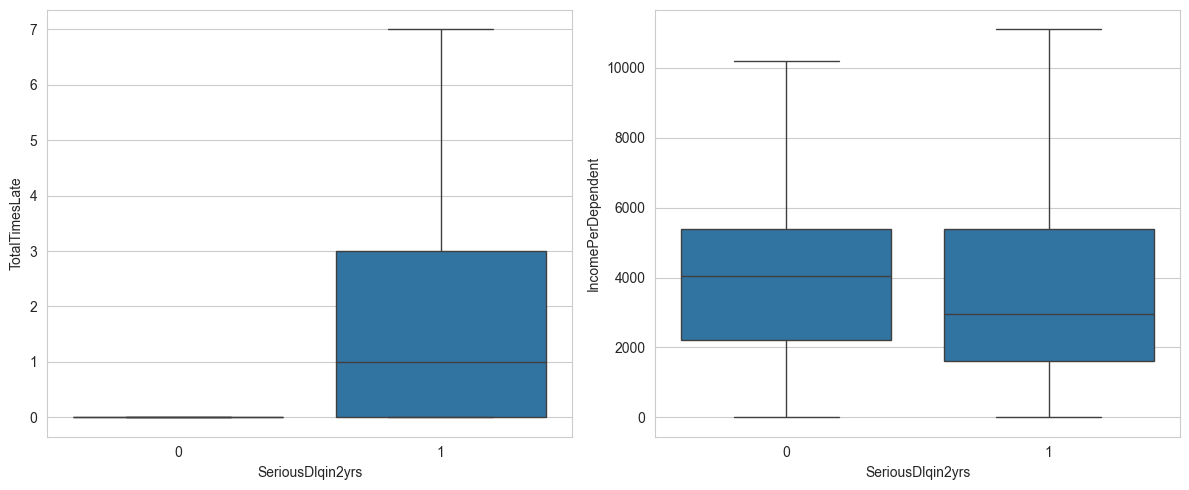

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='SeriousDlqin2yrs', y='TotalTimesLate', data=df, ax=axes[0], showfliers=False)
sns.boxplot(x='SeriousDlqin2yrs', y='IncomePerDependent', data=df, ax=axes[1], showfliers=False)
plt.tight_layout()
plt.show()

## 6. Train/validation split
Here I will split before any further processing to avoid leakage and stratify on the target since the dataset is imbalanced

In [12]:
from sklearn.model_selection import train_test_split
TARGET = "SeriousDlqin2yrs"
feature_cols = [c for c in df.columns if c != TARGET]

X = df[feature_cols]
y = df[TARGET]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, 
                                                  random_state=42)
print("Train:", X_train.shape, "Val:", X_val.shape)
print("Train positive rate:", y_train.mean().round(4))
print("Val positive rate:", y_val.mean().round(4))

Train: (119999, 15) Val: (30000, 15)
Train positive rate: 0.0668
Val positive rate: 0.0668


## 7. Save processed data

In [13]:
X_train.assign(**{TARGET: y_train}).to_csv("../data/processed/train.csv", index=False)
X_val.assign(**{TARGET: y_val}).to_csv("../data/processed/val.csv", index=False)
print("Saved to data/processed")

Saved to data/processed


## 8. Summary of cleaning & feature engineering decisions
* Filled `NumberOfDependents` null values with 0 and performed median imputation for `MonthlyIncome`. A flag checking missing value for monthly income was also added
* Removed the one where `age == 0` and capped the three "times late" columns to around 20; between 269-270 rows were ultimately capped (0.18% of all rows)
* The extreme outliers in Revolving unsecured lines and debt ratio were capped to the 99.5th percentile, which affected 750 rows
* Four columns were engineered: counting the number of times a user was past due on a payment, income per dependents, a binary has real estate loan, and a utilization bucket that will be useful in a logistic regression baseline model
* The final training dataset shape (119999, 15) and validation dataset shape (30000, 15) with a train and validation positive rate 0.0068